In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Dataset: Sectors_test  
Training: 2010–2016  
Universe: all sectors  
Selection: top 50 stocks by individual Sharpe ratio after missing-data filter  
Portfolio size test: k = 1 to 50  
Final k selection: smallest k within 5% of the best out-of-sample Sharpe  

#### **How does the number of stocks included in an equal-weight, sector-based portfolio affect its risk-adjusted performance, and what portfolio size provides a good balance between Sharpe ratio, diversification, and simplicity**

i.e. What is the most practical portfolio size after sector-based stock selection?

In [2]:
# Folder containing sector CSV files
sector_test_dir = r"C:\Users\User\OneDrive - Monash University\Documents\Monash\y2s2\ADS2001\Project\Latest\Sectors_test"

# Configuration
RISK_FREE_RATE = 0.02
MIN_DAYS = 252

TRAINING_START = "2010-01-01"
TRAINING_END = "2016-12-31"

TESTING_START = "2017-01-01"
TESTING_END = "2019-12-31"

TOP_K = 50
MAX_EFFECTIVE_MISSING_PCT = 20

In [3]:
file_list = []

for file in os.listdir(sector_test_dir):
    if file.endswith(".csv"):
        file_path = os.path.join(sector_test_dir, file)
        file_list.append(file_path)

print(f"Found {len(file_list)} sector files:")
for file in file_list:
    print(os.path.basename(file))

Found 12 sector files:
Basic_Materials.csv
Communication_Services.csv
Consumer_Cyclical.csv
Consumer_Defensive.csv
Energy.csv
Financial_Services.csv
Healthcare.csv
Industrials.csv
Real_Estate.csv
Technology.csv
Unknown.csv
Utilities.csv


In [4]:
def load_sector_returns(file_path, start_date, end_date):
    """
    Load one sector CSV and subset it to a selected date period.
    """
    sector_name = os.path.basename(file_path).replace(".csv", "")
    
    df = pd.read_csv(file_path)
    
    # Handle Date column
    df["Date"] = pd.to_datetime(df["Date"])
    df.set_index("Date", inplace=True)
    
    # Keep selected period only
    df = df.loc[start_date:end_date]
    
    if df.empty:
        print(f"Warning: no data for {sector_name}")
        return None, sector_name
    
    # Remove first row if all values are zero
    if (df.iloc[0] == 0).all():
        df = df.iloc[1:]
    
    print(f"{sector_name}: {df.shape[1]} stocks, {df.shape[0]} days")
    
    return df, sector_name

In [5]:
def calculate_sharpe(returns_series, risk_free_rate=RISK_FREE_RATE, min_obs=MIN_DAYS):
    """
    Calculate annualised Sharpe ratio for one stock.
    Zeros are treated as missing values.
    """
    clean_series = returns_series.replace(0, np.nan)
    valid_returns = clean_series.dropna()
    
    if len(valid_returns) < min_obs:
        return np.nan
    
    annual_return = valid_returns.mean() * 252
    annual_volatility = valid_returns.std() * np.sqrt(252)
    
    if annual_volatility > 0:
        sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility
    else:
        sharpe_ratio = np.nan
    
    return sharpe_ratio

In [6]:
print("=" * 60)
print("CALCULATING SHARPE RATIOS FOR ALL SECTORS")
print("=" * 60)

all_results = []
sector_summaries = []
sector_data = {}

for file_path in file_list:
    
    sector_returns, sector_name = load_sector_returns(
        file_path,
        TRAINING_START,
        TRAINING_END
    )
    
    if sector_returns is None:
        continue
    
    sector_data[sector_name] = sector_returns
    
    print(f"\nProcessing {sector_name}...")
    
    sector_results = []
    
    for stock in sector_returns.columns:
        sharpe = calculate_sharpe(sector_returns[stock])
        
        if not np.isnan(sharpe):
            sector_results.append({
                "Sector": sector_name,
                "Stock": stock,
                "Sharpe": sharpe
            })
            
            all_results.append({
                "Sector": sector_name,
                "Stock": stock,
                "Sharpe": sharpe
            })
    
    sector_results_df = pd.DataFrame(sector_results)
    
    if len(sector_results_df) > 0:
        sector_results_df = sector_results_df.sort_values("Sharpe", ascending=False)
        
        best_stock = sector_results_df.iloc[0]["Stock"]
        best_sharpe = sector_results_df.iloc[0]["Sharpe"]
        avg_sharpe = sector_results_df["Sharpe"].mean()
    else:
        best_stock = None
        best_sharpe = np.nan
        avg_sharpe = np.nan
    
    sector_summaries.append({
        "Sector": sector_name,
        "Total_Stocks": len(sector_returns.columns),
        "Qualified_Stocks": len(sector_results),
        "Best_Stock": best_stock,
        "Best_Sharpe": best_sharpe,
        "Avg_Sharpe": avg_sharpe
    })
    
    print(f"Qualified stocks: {len(sector_results)} / {len(sector_returns.columns)}")
    
    if best_stock is not None:
        print(f"Best Sharpe: {best_sharpe:.4f} ({best_stock})")

CALCULATING SHARPE RATIOS FOR ALL SECTORS
Basic_Materials: 20 stocks, 1825 days

Processing Basic_Materials...
Qualified stocks: 20 / 20
Best Sharpe: 1.0394 (SHW US Equity)
Communication_Services: 15 stocks, 1825 days

Processing Communication_Services...
Qualified stocks: 15 / 15
Best Sharpe: 1.0345 (CMCSA US Equity)
Consumer_Cyclical: 65 stocks, 1825 days

Processing Consumer_Cyclical...
Qualified stocks: 65 / 65
Best Sharpe: 1.2999 (ORLY US Equity)
Consumer_Defensive: 30 stocks, 1825 days

Processing Consumer_Defensive...
Qualified stocks: 30 / 30
Best Sharpe: 1.4188 (MO US Equity)
Energy: 27 stocks, 1825 days

Processing Energy...
Qualified stocks: 27 / 27
Best Sharpe: 1.4096 (EP US Equity)
Financial_Services: 59 stocks, 1825 days

Processing Financial_Services...
Qualified stocks: 58 / 59
Best Sharpe: 1.0204 (CINF US Equity)
Healthcare: 51 stocks, 1825 days

Processing Healthcare...
Qualified stocks: 49 / 51
Best Sharpe: 1.1114 (UNH US Equity)
Industrials: 67 stocks, 1825 days

Pr

In [7]:
all_results_df = pd.DataFrame(all_results).sort_values("Sharpe", ascending=False)
sector_summary_df = pd.DataFrame(sector_summaries)

print("=" * 60)
print("TOP 20 STOCKS BY SHARPE RATIO")
print("=" * 60)
display(all_results_df.head(20))

print("=" * 60)
print("SECTOR SUMMARY")
print("=" * 60)
display(sector_summary_df)

TOP 20 STOCKS BY SHARPE RATIO


,Sector,Stock,Sharpe
119,Consumer_Defensive,MO US Equity,1.418750
137,Energy,EP US Equity,1.409623
415,Unknown,0961514D US Equity,1.398497
516,Unknown,GENZ US Equity,1.374545
586,Unknown,RAI US Equity,1.342510
80,Consumer_Cyclical,ORLY US Equity,1.299917
342,Real_Estate,EXR US Equity,1.287389
40,Consumer_Cyclical,AZO US Equity,1.259883
307,Industrials,NOC US Equity,1.243472
531,Unknown,HSH US Equity,1.209874


SECTOR SUMMARY


,Sector,Total_Stocks,Qualified_Stocks,Best_Stock,Best_Sharpe,Avg_Sharpe
0,Basic_Materials,20,20,SHW US Equity,1.039434,0.482398
1,Communication_Services,15,15,CMCSA US Equity,1.034510,0.660015
2,Consumer_Cyclical,65,65,ORLY US Equity,1.299917,0.591424
3,Consumer_Defensive,30,30,MO US Equity,1.418750,0.761610
4,Energy,27,27,EP US Equity,1.409623,0.332050
5,Financial_Services,59,58,CINF US Equity,1.020395,0.531037
6,Healthcare,51,49,UNH US Equity,1.111361,0.632406
7,Industrials,67,67,NOC US Equity,1.243472,0.617509
8,Real_Estate,30,30,EXR US Equity,1.287389,0.648666
9,Technology,51,50,IT US Equity,1.056103,0.550261


In [8]:
missing_rows = []

for _, row in all_results_df.iterrows():
    stock = row["Stock"]
    sector = row["Sector"]
    
    if sector not in sector_data:
        continue
    
    if stock not in sector_data[sector].columns:
        continue
    
    s = sector_data[sector][stock]
    
    missing_count = s.isna().sum()
    zero_count = (s == 0).sum()
    effective_missing_count = (s.isna() | (s == 0)).sum()
    total_count = len(s)
    
    missing_rows.append({
        "Stock": stock,
        "Sector": sector,
        "Missing_count": missing_count,
        "Missing_pct": missing_count / total_count * 100,
        "Zero_return_count": zero_count,
        "Zero_return_pct": zero_count / total_count * 100,
        "Effective_missing_count_NaN_or_zero": effective_missing_count,
        "Effective_missing_pct_NaN_or_zero": effective_missing_count / total_count * 100
    })

missing_summary = pd.DataFrame(missing_rows)

valid_stocks = missing_summary.loc[
    missing_summary["Effective_missing_pct_NaN_or_zero"] <= MAX_EFFECTIVE_MISSING_PCT,
    "Stock"
]

all_results_df_filtered = all_results_df[
    all_results_df["Stock"].isin(valid_stocks)
].copy()

top_stocks = all_results_df_filtered.head(TOP_K)["Stock"].tolist()

top_stocks_with_sectors = all_results_df_filtered.head(TOP_K)[
    ["Stock", "Sector", "Sharpe"]
].copy()

print("=" * 60)
print(f"TOP {len(top_stocks)} STOCKS SELECTED AFTER MISSING-DATA FILTER")
print("=" * 60)
print(f"Training period: {TRAINING_START} to {TRAINING_END}")
print(f"Maximum effective missing allowed: {MAX_EFFECTIVE_MISSING_PCT}%")

display(top_stocks_with_sectors)

print("Missing-data summary for selected stocks:")
selected_missing_summary = missing_summary[
    missing_summary["Stock"].isin(top_stocks)
].sort_values("Effective_missing_pct_NaN_or_zero", ascending=False)

display(selected_missing_summary.round(2))

TOP 50 STOCKS SELECTED AFTER MISSING-DATA FILTER
Training period: 2010-01-01 to 2016-12-31
Maximum effective missing allowed: 20%


,Stock,Sector,Sharpe
119,MO US Equity,Consumer_Defensive,1.418750
586,RAI US Equity,Unknown,1.342510
80,ORLY US Equity,Consumer_Cyclical,1.299917
342,EXR US Equity,Real_Estate,1.287389
40,AZO US Equity,Consumer_Cyclical,1.259883
307,NOC US Equity,Industrials,1.243472
60,HD US Equity,Consumer_Cyclical,1.200028
86,ROST US Equity,Consumer_Cyclical,1.195322
300,LMT US Equity,Industrials,1.162321
652,NI US Equity,Utilities,1.153977


Missing-data summary for selected stocks:


,Stock,Sector,Missing_count,Missing_pct,Zero_return_count,Zero_return_pct,Effective_missing_count_NaN_or_zero,Effective_missing_pct_NaN_or_zero
18,CMCSK US Equity,Unknown,70,3.84,271,14.85,341,18.68
46,BSET US Equity,Consumer_Cyclical,0,0.00,122,6.68,122,6.68
41,ACAS US Equity,Unknown,0,0.00,100,5.48,100,5.48
26,EVRG US Equity,Utilities,0,0.00,92,5.04,92,5.04
0,MO US Equity,Consumer_Defensive,0,0.00,88,4.82,88,4.82
35,MMC US Equity,Unknown,0,0.00,88,4.82,88,4.82
59,TSN US Equity,Consumer_Defensive,0,0.00,85,4.66,85,4.66
13,NI US Equity,Utilities,0,0.00,85,4.66,85,4.66
6,EXR US Equity,Real_Estate,0,0.00,84,4.60,84,4.60
37,CMS US Equity,Utilities,0,0.00,82,4.49,82,4.49


In [9]:
top_returns = []

for _, row in top_stocks_with_sectors.iterrows():
    stock = row["Stock"]
    sector = row["Sector"]
    
    stock_series = sector_data[sector][stock].copy()
    stock_series = stock_series.replace(0, np.nan)
    stock_series.name = stock
    
    top_returns.append(stock_series)

returns_top = pd.concat(top_returns, axis=1)

# Drop rows where all stocks are missing
returns_clean = returns_top.dropna(how="all")

# Keep rows where at least 80% of stocks have valid data
min_valid_stocks = int(0.8 * len(top_stocks))
returns_clean = returns_clean.dropna(thresh=min_valid_stocks)

# Fill remaining missing values with 0
returns_clean = returns_clean.fillna(0)

print("Top 50 returns shape after cleaning:", returns_clean.shape)
display(returns_clean.head())

Top 50 returns shape after cleaning: (1762, 50)


,MO US Equity,RAI US Equity,ORLY US Equity,EXR US Equity,AZO US Equity,NOC US Equity,HD US Equity,ROST US Equity,LMT US Equity,NI US Equity,...,COST US Equity,LNT US Equity,AYI US Equity,AGN US Equity,TSN US Equity,NFLX US Equity,MKC US Equity,BKNG US Equity,HSY US Equity,KR US Equity
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,0.008149,0.005092,0.009969,0.029436,-0.000253,0.017916,-0.008985,-0.000461,0.019902,0.008451,...,0.004053,0.002972,0.010951,0.017173,-0.002445,-0.029225,0.004705,0.025411,0.012014,-0.002436
2010-01-05,0.000501,0.001129,0.001558,-0.006732,-0.008353,0.001743,0.007313,0.018273,0.010407,-0.002591,...,-0.003028,0.023391,0.008315,-0.009925,0.018785,-0.036780,-0.002755,0.011609,0.026227,-0.011719
2010-01-06,0.014647,0.012947,-0.004409,0.003389,-0.009380,0.003862,-0.003439,0.015408,-0.014684,-0.011631,...,0.012988,0.007733,0.014315,0.003255,0.050522,0.035059,0.003867,-0.033016,-0.008608,0.000494
2010-01-07,-0.001489,-0.011116,-0.003126,-0.007596,0.013270,0.010331,0.011801,0.041004,-0.027440,-0.012431,...,-0.004827,0.005425,0.031203,-0.008009,0.017560,-0.017198,0.007704,-0.013465,-0.009769,0.009877
2010-01-08,0.002488,-0.004677,-0.008884,-0.022104,-0.012842,-0.005547,-0.004800,-0.019366,0.016123,-0.005299,...,-0.007200,0.019382,0.003692,-0.007295,-0.002250,0.017099,0.002731,0.000370,-0.003015,-0.009291


In [10]:
# --------------------------------------------------
# Equal-weight Portfolio Size Analysis
# --------------------------------------------------
# This section isolates the effect of portfolio size.
# No weight optimisation is applied here.
# For each k, every stock receives the same weight: 1/k.

ordered_stocks = top_stocks_with_sectors["Stock"].tolist()

portfolio_size_results = []

print("=" * 60)
print("EQUAL-WEIGHT PORTFOLIO SIZE ANALYSIS")
print("=" * 60)

for k in range(1, len(ordered_stocks) + 1):
    
    selected_stocks_k = ordered_stocks[:k]
    returns_k = returns_clean[selected_stocks_k]
    
    # Equal weights
    weights = np.repeat(1 / k, k)
    
    # Daily portfolio returns
    portfolio_daily_returns = returns_k @ weights
    
    # Annualised performance
    annual_return = portfolio_daily_returns.mean() * 252
    annual_risk = portfolio_daily_returns.std() * np.sqrt(252)
    
    if annual_risk > 0:
        sharpe_ratio = (annual_return - RISK_FREE_RATE) / annual_risk
    else:
        sharpe_ratio = np.nan
    
    portfolio_size_results.append({
        "k": k,
        "Annual_Return": annual_return,
        "Annual_Risk": annual_risk,
        "Sharpe_Ratio": sharpe_ratio
    })
    
    print(
        f"k = {k:2d} | "
        f"Return = {annual_return:.4f} | "
        f"Risk = {annual_risk:.4f} | "
        f"Sharpe = {sharpe_ratio:.4f}"
    )

portfolio_size_df = pd.DataFrame(portfolio_size_results)

display(portfolio_size_df.head())

EQUAL-WEIGHT PORTFOLIO SIZE ANALYSIS
k =  1 | Return = 0.2395 | Risk = 0.1560 | Sharpe = 1.4067
k =  2 | Return = 0.2565 | Risk = 0.1610 | Sharpe = 1.4686
k =  3 | Return = 0.2741 | Risk = 0.1496 | Sharpe = 1.6989
k =  4 | Return = 0.2889 | Risk = 0.1522 | Sharpe = 1.7664
k =  5 | Return = 0.2803 | Risk = 0.1446 | Sharpe = 1.8009
k =  6 | Return = 0.2775 | Risk = 0.1417 | Sharpe = 1.8174
k =  7 | Return = 0.2756 | Risk = 0.1414 | Sharpe = 1.8075
k =  8 | Return = 0.2783 | Risk = 0.1422 | Sharpe = 1.8157
k =  9 | Return = 0.2722 | Risk = 0.1388 | Sharpe = 1.8168
k = 10 | Return = 0.2691 | Risk = 0.1370 | Sharpe = 1.8177
k = 11 | Return = 0.2784 | Risk = 0.1395 | Sharpe = 1.8522
k = 12 | Return = 0.2880 | Risk = 0.1444 | Sharpe = 1.8562
k = 13 | Return = 0.2854 | Risk = 0.1445 | Sharpe = 1.8371
k = 14 | Return = 0.2807 | Risk = 0.1433 | Sharpe = 1.8194
k = 15 | Return = 0.2807 | Risk = 0.1429 | Sharpe = 1.8245
k = 16 | Return = 0.2830 | Risk = 0.1454 | Sharpe = 1.8095
k = 17 | Return = 0

,k,Annual_Return,Annual_Risk,Sharpe_Ratio
0,1,0.239461,0.156007,1.406741
1,2,0.256450,0.161000,1.468639
2,3,0.274134,0.149591,1.698855
3,4,0.288852,0.152204,1.766394
4,5,0.280339,0.144560,1.800913


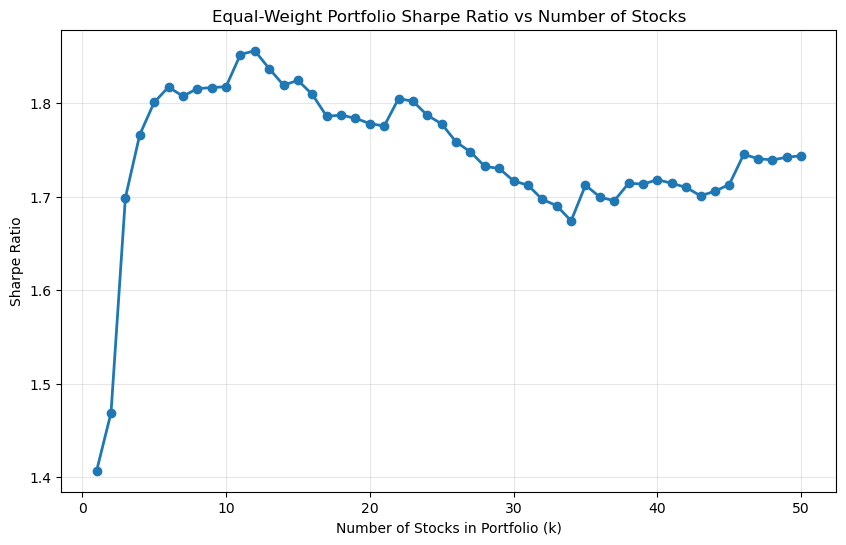

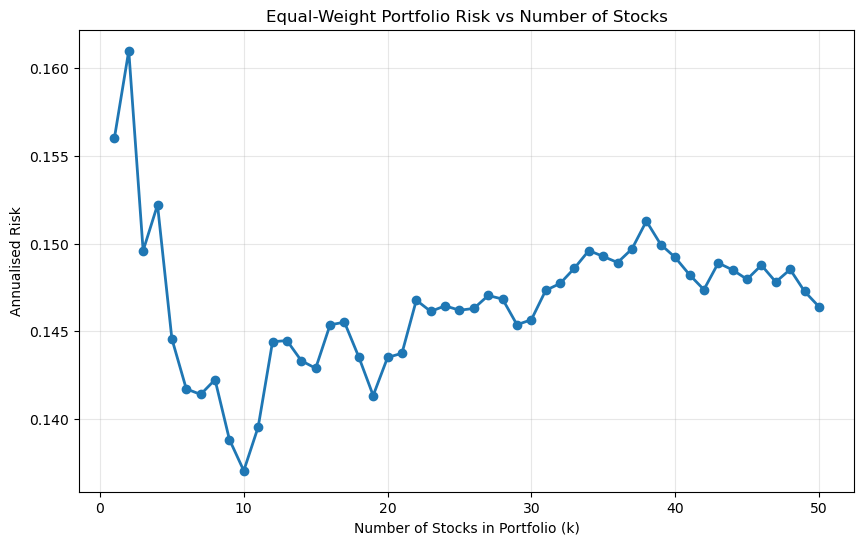

In [11]:
# --------------------------------------------------
# Visualise portfolio size results
# --------------------------------------------------

# Graph 1: Sharpe ratio vs number of stocks
plt.figure(figsize=(10, 6))

plt.plot(
    portfolio_size_df["k"],
    portfolio_size_df["Sharpe_Ratio"],
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Stocks in Portfolio (k)")
plt.ylabel("Sharpe Ratio")
plt.title("Equal-Weight Portfolio Sharpe Ratio vs Number of Stocks")
plt.grid(True, alpha=0.3)

plt.show()


# Graph 2: Risk vs number of stocks
plt.figure(figsize=(10, 6))

plt.plot(
    portfolio_size_df["k"],
    portfolio_size_df["Annual_Risk"],
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Stocks in Portfolio (k)")
plt.ylabel("Annualised Risk")
plt.title("Equal-Weight Portfolio Risk vs Number of Stocks")
plt.grid(True, alpha=0.3)

plt.show()

In [12]:
# --------------------------------------------------
# Choose practical portfolio size
# --------------------------------------------------
# Rule:
# Select the smallest k that achieves at least 95%
# of the best equal-weight Sharpe ratio.

best_sharpe = portfolio_size_df["Sharpe_Ratio"].max()

best_k_row = portfolio_size_df.loc[
    portfolio_size_df["Sharpe_Ratio"].idxmax()
]

best_k = int(best_k_row["k"])

print(f"Best equal-weight Sharpe Ratio: {best_sharpe:.4f}")
print(f"Recommended portfolio size based on maximum Sharpe: k = {best_k}")

display(best_k_row)

selected_final_stocks = ordered_stocks[:best_k]

selected_final_stocks_df = top_stocks_with_sectors[
    top_stocks_with_sectors["Stock"].isin(selected_final_stocks)
].reset_index(drop=True)

print("Selected stocks for weight optimisation:")
display(selected_final_stocks_df)

Best equal-weight Sharpe Ratio: 1.8562
Recommended portfolio size based on maximum Sharpe: k = 12


k                12.000000
Annual_Return     0.288031
Annual_Risk       0.144395
Sharpe_Ratio      1.856231
Name: 11, dtype: float64

Selected stocks for weight optimisation:


,Stock,Sector,Sharpe
0,MO US Equity,Consumer_Defensive,1.418750
1,RAI US Equity,Unknown,1.342510
2,ORLY US Equity,Consumer_Cyclical,1.299917
3,EXR US Equity,Real_Estate,1.287389
4,AZO US Equity,Consumer_Cyclical,1.259883
5,NOC US Equity,Industrials,1.243472
6,HD US Equity,Consumer_Cyclical,1.200028
7,ROST US Equity,Consumer_Cyclical,1.195322
8,LMT US Equity,Industrials,1.162321
9,NI US Equity,Utilities,1.153977


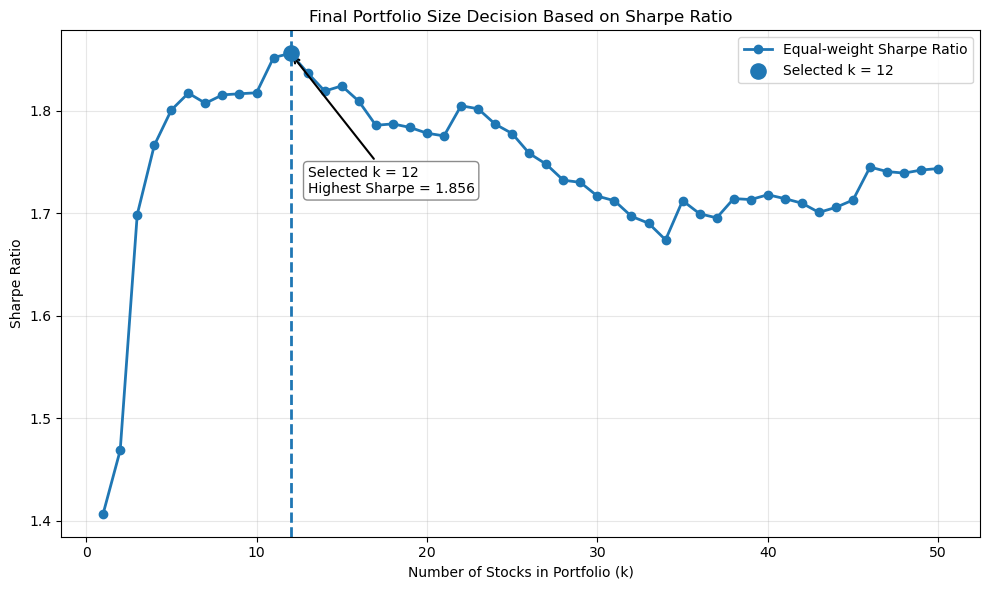

In [17]:
# --------------------------------------------------
# Annotated Sharpe Ratio Graph for Final Decision
# --------------------------------------------------

# Find best Sharpe point
best_sharpe = portfolio_size_df["Sharpe_Ratio"].max()

best_k_row = portfolio_size_df.loc[
    portfolio_size_df["Sharpe_Ratio"].idxmax()
]

best_k = int(best_k_row["k"])

plt.figure(figsize=(10, 6))

# Main Sharpe line
plt.plot(
    portfolio_size_df["k"],
    portfolio_size_df["Sharpe_Ratio"],
    marker="o",
    linewidth=2,
    label="Equal-weight Sharpe Ratio"
)

# Highlight selected/best k point
plt.scatter(
    best_k,
    best_sharpe,
    s=120,
    zorder=5,
    label=f"Selected k = {best_k}"
)

# Vertical line at selected k
plt.axvline(
    x=best_k,
    linestyle="--",
    linewidth=2
)

# Put annotation in empty space on the right
plt.annotate(
    f"Selected k = {best_k}\nHighest Sharpe = {best_sharpe:.3f}",
    xy=(best_k, best_sharpe),          # point being labelled
    xytext=(13, 1.72),                 # move label box to empty space
    textcoords="data",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.5
    ),
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="white",
        ec="gray",
        alpha=0.9
    )
)

plt.xlabel("Number of Stocks in Portfolio (k)")
plt.ylabel("Sharpe Ratio")
plt.title("Final Portfolio Size Decision Based on Sharpe Ratio")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()